In [1]:
# Install required libraries
!pip install opendatasets librosa opencv-python-headless --quiet

import opendatasets as od
import os
import pandas as pd
import numpy as np
import cv2
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import copy
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download the dataset
print("Downloading dataset...")
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")
base_dir = "quran-recitations-for-audio-classification"
print("Download complete.")

Skipping, found downloaded files in "./quran-recitations-for-audio-classification" (use force=True to force download)
Download complete.


Dataloading and Preprocessing

In [12]:
# Load metadata
df = pd.read_csv(os.path.join(base_dir, "files_paths.csv"))

# Identify column names dynamically
file_col = 'FilePath' if 'FilePath' in df.columns else 'file_path'
label_col = 'Class' if 'Class' in df.columns else 'label'

# Create class mappings
classes = sorted(df[label_col].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
num_classes = len(classes)
print(f"Found {num_classes} reciters: {classes}")

# Split into train and test sets (80/20 split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[label_col])

def audio_to_melspectrogram(audio_path, img_size=(224, 224)):
    """Converts an audio file to a 3-channel Mel-Spectrogram image."""
    # Load audio at a standard sample rate
    y, sr = librosa.load(audio_path, sr=22050)

    # Compute Mel-Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

    # Convert to decibel scale (logarithmic)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalize to 0-255 for image representation
    mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
    mel_spec_db = (mel_spec_db * 255).astype(np.uint8)

    # Resize to target image size
    img = cv2.resize(mel_spec_db, img_size)

    # Convert grayscale to 3 channels (RGB) to use pre-trained CNNs
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img

class QuranAudioDataset(Dataset):
    def __init__(self, dataframe, base_dir, file_col, label_col, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.file_col = file_col
        self.label_col = label_col
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        rel_path = row[self.file_col]

        # Robust path finding (handles various subdirectory structures)
        possible_paths = [
            os.path.join(self.base_dir, rel_path),
            os.path.join(self.base_dir, "Dataset", rel_path),
            os.path.join(self.base_dir, "Dataset", "Dataset", rel_path),
            os.path.join(self.base_dir, os.path.basename(rel_path))
        ]

        audio_path = next((p for p in possible_paths if os.path.exists(p)), None)
        if audio_path is None:
            raise FileNotFoundError(f"Could not find audio file: {rel_path}")

        # Convert to image
        img = audio_to_melspectrogram(audio_path)

        # Apply transformations
        if self.transform:
            img = self.transform(img)

        label = self.class_to_idx[row[self.label_col]]
        return img, label

# Define transformations
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets and dataloaders
train_dataset = QuranAudioDataset(train_df, base_dir, file_col, label_col, class_to_idx, transform=train_transform)
test_dataset = QuranAudioDataset(test_df, base_dir, file_col, label_col, class_to_idx, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Found 12 reciters: ['AbdulBari_Althubaity', 'AbdulRahman_Alsudais', 'Abdullah_Albuaijan', 'Ali_Alhothaify', 'Bander_Balilah', 'Maher_Almuaiqly', 'Mohammed_Aluhaidan', 'Mohammed_Ayoub', 'Nasser_Alqutami', 'Saad_Alghamdi', 'Saud_Alshuraim', 'Yasser_Aldossary']


Model Definition

In [15]:
# Use ResNet18 and train it from scratch
model = models.resnet18(weights=None)

# Replace the final fully connected layer to match our number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Only optimize the parameters of the model
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training Loop

In [16]:
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = test_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())

            # Deep copy the model if it has the best validation accuracy
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print()

print(f'Best val Acc: {best_acc:.4f}')
model.load_state_dict(best_model_wts)

Epoch 1/10
----------
train Loss: 0.6435 Acc: 0.7981
val Loss: 0.2304 Acc: 0.9185

Epoch 2/10
----------
train Loss: 0.1690 Acc: 0.9499
val Loss: 0.0893 Acc: 0.9738

Epoch 3/10
----------
train Loss: 0.0924 Acc: 0.9733
val Loss: 0.1365 Acc: 0.9537

Epoch 4/10
----------
train Loss: 0.0802 Acc: 0.9766
val Loss: 0.1853 Acc: 0.9439

Epoch 5/10
----------
train Loss: 0.0509 Acc: 0.9854
val Loss: 0.0534 Acc: 0.9821

Epoch 6/10
----------
train Loss: 0.0301 Acc: 0.9910
val Loss: 0.0567 Acc: 0.9828

Epoch 7/10
----------
train Loss: 0.0284 Acc: 0.9916
val Loss: 0.0607 Acc: 0.9813

Epoch 8/10
----------
train Loss: 0.0447 Acc: 0.9830
val Loss: 0.2302 Acc: 0.9335

Epoch 9/10
----------
train Loss: 0.0955 Acc: 0.9703
val Loss: 0.0343 Acc: 0.9903

Epoch 10/10
----------
train Loss: 0.0264 Acc: 0.9921
val Loss: 0.0183 Acc: 0.9933

Best val Acc: 0.9933


<All keys matched successfully>

Training Report

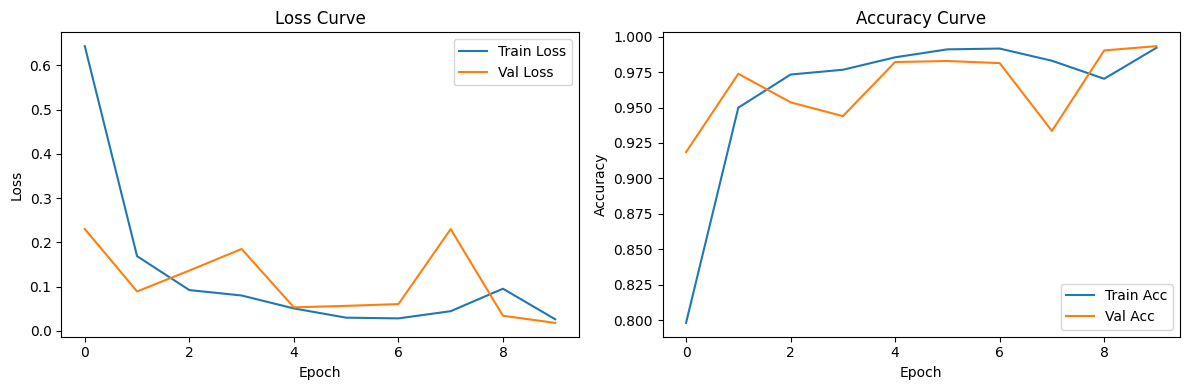

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy Score

In [18]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 99.33%


Live Demo

In [19]:
def predict_reciter(audio_path, model, class_to_idx, idx_to_class, device, base_dir):
    model.eval()

    # Robust path finding
    if not os.path.exists(audio_path):
        for root, dirs, files in os.walk(base_dir):
            if os.path.basename(audio_path) in files:
                audio_path = os.path.join(root, os.path.basename(audio_path))
                break

    if not os.path.exists(audio_path):
        print(f"Error: File not found at {audio_path}")
        return

    # Convert audio to image
    img = audio_to_melspectrogram(audio_path, img_size=(224, 224))

    # Apply test transformations
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs[0], dim=0)
        top3_probs, top3_idxs = torch.topk(probs, 3)

    print(f"Predicted Reciter: {idx_to_class[top3_idxs[0].item()]}")
    print("Top 3 Predictions:")
    for i in range(3):
        print(f"  {idx_to_class[top3_idxs[i].item()]}: {top3_probs[i].item() * 100:.2f}%")

# --- DEMO ---
# Pick a random file from the test set to demonstrate
demo_rel_path = test_df.iloc[0][file_col]
print(f"Demo Audio Path: {demo_rel_path}")
predict_reciter(demo_rel_path, model, class_to_idx, idx_to_class, device, base_dir)

Demo Audio Path: ./Dataset/Yasser_Aldossary/Yasser_448.wav
Predicted Reciter: Yasser_Aldossary
Top 3 Predictions:
  Yasser_Aldossary: 98.74%
  Saud_Alshuraim: 1.25%
  Mohammed_Ayoub: 0.00%


In [ ]:
!pip install gradio --quiet

import gradio as gr

def gradio_predict(audio_file):
    if audio_file is None:
        return "Please upload an audio file."

    model.eval()
    # Convert audio to image using the existing preprocessing function
    # audio_file here is the path provided by Gradio
    try:
        img = audio_to_melspectrogram(audio_file, img_size=(224, 224))
    except Exception as e:
        return f"Error processing audio: {str(e)}"

    # Apply transformations
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs[0], dim=0)
        top3_probs, top3_idxs = torch.topk(probs, 3)

    results = {}
    for i in range(3):
        label = idx_to_class[top3_idxs[i].item()]
        confidence = float(top3_probs[i].item())
        results[label] = confidence

    return results

# Define the Gradio Interface
interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Audio(type="filepath", label="Upload Quran Recitation"),
    outputs=gr.Label(num_top_classes=3, label="Prediction Confidence"),
    title="Quran Reciter Classifier",
    description="Upload an audio clip of a Quran recitation to identify the reciter among 12 famous Shuyookh.",
    examples=[
        [os.path.join(base_dir, test_df.iloc[0][file_col])],
        [os.path.join(base_dir, test_df.iloc[1][file_col])]
    ]
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://56c02c9435cf1a2cf7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
